<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/LDA_TP_Iris_JuanDAnc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Trabajo Práctico 3: Análisis Discriminante Lineal (LDA) aplicado al Dataset Iris

Tema: Linear Discriminant Analysis (LDA).

Materia: Inteligencia Artificial y modelos de regresión

Alumno: Juan Diego Ancarani.

Fecha: 26/5/2026.

In [2]:
# Imports y configuración inicial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 🔹 Sección 1: Exploración y Preprocesamiento

### ❓ Pregunta 1.1
> Cargá el dataset Iris y describí su estructura: cantidad de muestras, características, clases y tipos de datos.  
¿Existen valores nulos? Justificá tu respuesta con código y/o texto.

In [3]:
# 📝 CELDA 1.1: Cargar y explorar el dataset
# COMPLETAR: Cargar iris con sklearn, convertir a DataFrame y explorar
# Tu código aquí:

from sklearn.datasets import load_iris


iris_data = load_iris()
df = pd.DataFrame(data = iris_data.data, columns = iris_data.feature_names)
df['target'] = iris_data.target
df['species'] = df['target'].map({   #crear nueva columna 'especies' con el mapeo de 'target'..
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'})

print('--' *50)

print('--REPORTE: INFORMACIÓN GENERAL--')
df.info()

print('--' *50)

print('--REPORTE: VALORES NULOS--')
print(df.isnull().sum())

print('--' *50)
df.head(5)

----------------------------------------------------------------------------------------------------
--REPORTE: INFORMACIÓN GENERAL--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
----------------------------------------------------------------------------------------------------
--REPORTE: VALORES NULOS--
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64
-------------------------------------

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Pregunta 1.1 → no existen valores nulos

### ❓ Pregunta 1.2
> Generá un resumen estadístico descriptivo (media, desvío estándar, mínimo, máximo) para cada característica.  
¿Qué características presentan mayor variabilidad? ¿Hay correlaciones evidentes entre variables? Adjuntá un heatmap de correlaciones.

----------------------------------------------------------------------------------------------------
--REPORTE: ESTADÍSTICAS DESCRIPTIVAS--
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
----------------------------------------

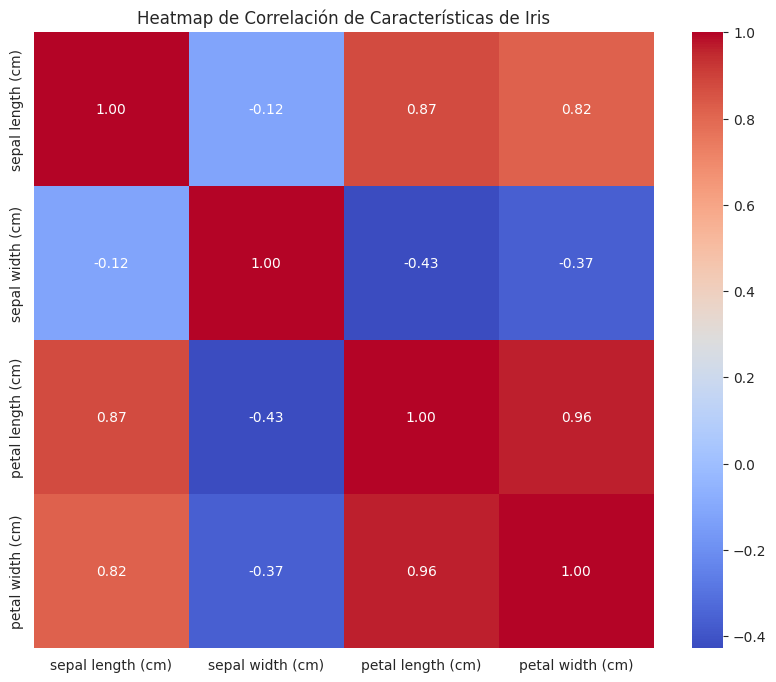

In [4]:
# 📝 CELDA 1.2: Estadísticos y correlaciones
# COMPLETAR: Calcular describe() y graficar heatmap de correlación
# Tu código aquí:

print('--' *50)
print('--REPORTE: ESTADÍSTICAS DESCRIPTIVAS--')
print(df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].describe())

print('--' *50)
print('--REPORTE: MATRIZ DE CORRELACIÓN--')
correlation_matrix = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm' ,fmt=".2f")
plt.title('Heatmap de Correlación de Características de Iris')
plt.show()

### ❓ Pregunta 1.3
> Visualizá la distribución de cada característica separada por especie usando boxplots o violin plots. ¿Qué variables parecen más discriminantes para separar las clases? Fundamentá tu respuesta observando los gráficos.

/tmp/ipykernel_15919/1983496698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'species', y = feature, ax = ax, palette = 'Set2', inner = 'quartile')
/tmp/ipykernel_15919/1983496698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'species', y = feature, ax = ax, palette = 'Set2', inner = 'quartile')
/tmp/ipykernel_15919/1983496698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'species', y = feature, ax = ax, palette = 'Set2', inner = 'quartile')
/tmp/ipykernel_15919/1983

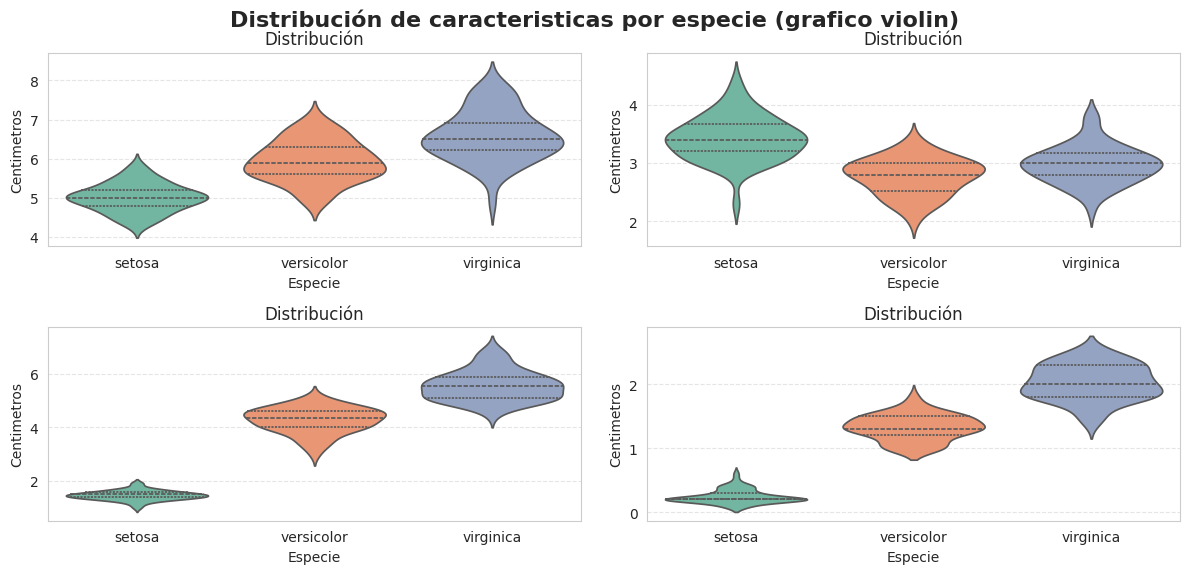

In [5]:
# 📝 CELDA 1.3: Visualización por clase
# COMPLETAR: Crear gráficos de distribución por especie
# Tu código aquí:

fig, axes = plt.subplots(2, 2, figsize = (12, 6))
fig.suptitle('Distribución de caracteristicas por especie (grafico violin)', fontsize = 16, fontweight = 'bold', y = 0.95)

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

for i, feature in enumerate(features):
  row, col = divmod(i, 2)
  ax = axes[row, col]

  sns.violinplot(data = df, x = 'species', y = feature, ax = ax, palette = 'Set2', inner = 'quartile')
  ax.set_title('Distribución')
  ax.set_xlabel('Especie')
  ax.set_ylabel('Centimetros')
  ax.grid(axis = 'y', linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

### ❓ Pregunta 1.4
> ¿Por qué es importante escalar las características antes de aplicar LDA? ¿Qué ocurre si no lo hacemos?  
  Aplicá `StandardScaler` y guardá los datos normalizados.

In [6]:
# 📝 CELDA 1.4: Escalado de características
# COMPLETAR: Aplicar StandardScaler y justificar en texto
# Tu código aquí:

scaler = StandardScaler()
iris_data_scaled = scaler.fit_transform(df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']])


## 🔹 Sección 2: Implementación y Aplicación de LDA

### ❓ Pregunta 2.1
> Aplicá LDA usando `sklearn` para reducir los datos a 2 componentes discriminantes. Mostrá el porcentaje de varianza explicada por cada componente. ¿Cuántos componentes máximos puede generar LDA para este dataset?.

In [7]:
# 📝 CELDA 2.1: Aplicar LDA con scikit-learn
# COMPLETAR: Instanciar LDA, ajustar y proyectar
# Tu código aquí:

X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['target']

LDA = LinearDiscriminantAnalysis(n_components = 2)
X_LDA = LDA.fit_transform(X, y)
varianza_explicada = LDA.explained_variance_ratio_

print('--REPORTE: ANALISIS DE VARIANZA EXPLICADA X AMBOS COMPONENTES--')
for i, var in enumerate(varianza_explicada):
  print(f' Componente discriminante: {i + 1}: {var*100:.2f}% de la varianza ')


print(f' Varianza total retenida por los 2 componentes: {sum(varianza_explicada) *100:.2f}%')

--REPORTE: ANALISIS DE VARIANZA EXPLICADA X AMBOS COMPONENTES--
 Componente discriminante: 1: 99.12% de la varianza 
 Componente discriminante: 2: 0.88% de la varianza 
 Varianza total retenida por los 2 componentes: 100.00%


Pregunta 3.1 → Al ser una problema de 3 dimensiones, genera un total de 3 componentes discriminantes. Lo importante aquí es que el primer componente captura el 99% de la variabilidad. Es decir que, si queremos capturar datos con una sola dimensión, obtendremos el 99% de ellos. Solo el 0.88% restante, tendríamos que proyectar otra dimensión.

* En este caso teniamos 3 clases disponibles (setosa, versicolor y virginica), el número máximo de componentes discriminantes que LDA puede calcular es: C - 1 (3-1 = 2).

### ❓ Pregunta 2.2
> Visualizá los datos proyectados en el espacio 2D de LDA. Coloreá cada punto según su especie real. ¿Se observa una buena separación entre clases? ¿Qué pares de especies son más difíciles de distinguir?

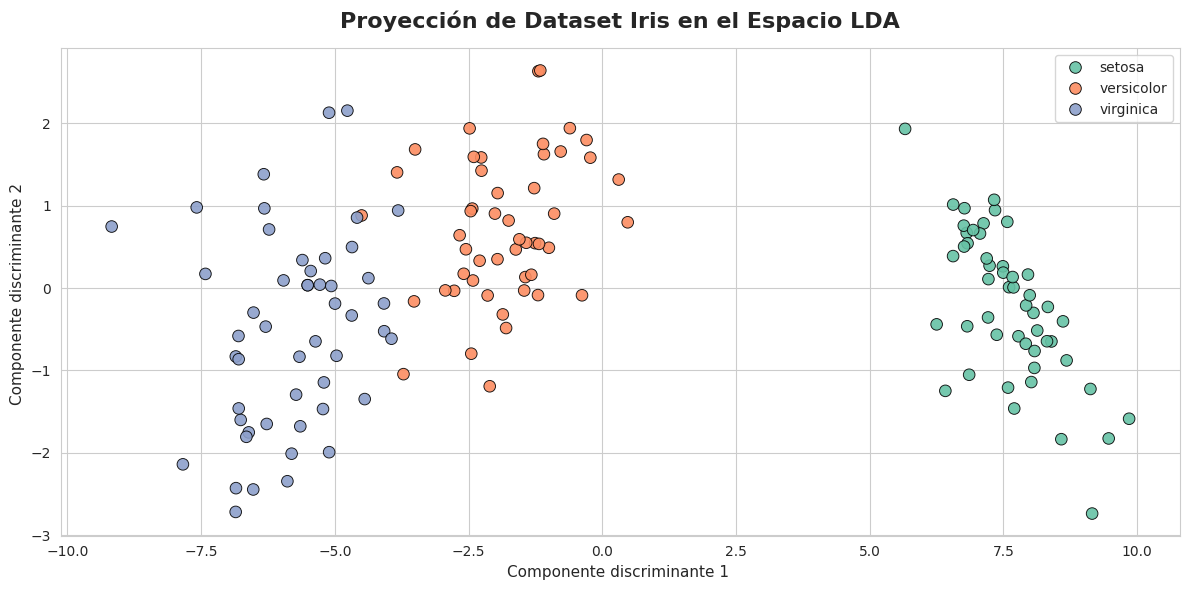

In [8]:
# 📝 CELDA 2.2: Scatter plot en espacio LDA
# COMPLETAR: Graficar proyección LDA con leyenda y etiquetas
# Tu código aquí:

plt.figure(figsize = (12,6))

## X_lda tiene 2 columnas: la primera es el Componente 1 y la segunda el Componente 2

sns.scatterplot(
    x = X_LDA[:, 0],
    y = X_LDA[:, 1],
    hue = df['species'],
    palette = 'Set2',
    s=70,
    alpha = 0.9,
    edgecolor = 'k'

)

plt.title('Proyección de Dataset Iris en el Espacio LDA', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Componente discriminante 1 ', fontsize = 11)
plt.ylabel('Componente discriminante 2 ', fontsize = 11)
plt.legend()


plt.tight_layout()
plt.show()

### ❓ Pregunta 2.3
> Interpretá los *loadings* (coeficientes) de cada característica en los componentes discriminantes. ¿Qué variables tienen mayor peso en LD1 y LD2? ¿Cómo se relaciona esto con lo observado en la Pregunta 1.3?

In [9]:
# 📝 CELDA 2.3: Analizar coeficientes de LDA
# COMPLETAR: Extraer y visualizar coeficientes de LDA
# Tu código aquí:

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

#Creamos DataFrame con los coeficientes

#Determinar componentes.
num_components = LDA.coef_.T.shape[1]
column_names = [f'LD{i+1} (pesos)' for i in range(num_components)]

coef_df = pd.DataFrame(
           data = LDA.coef_.T,
           columns = column_names, # Use dynamically generated column names
           index = features
           )

print('-- REPORTE: COEFICIENTES DE LDA --')
print(coef_df.round(4))


-- REPORTE: COEFICIENTES DE LDA --
                   LD1 (pesos)  LD2 (pesos)  LD3 (pesos)
sepal length (cm)       6.3148      -1.5312      -4.7836
sepal width (cm)       12.1393      -4.3760      -7.7633
petal length (cm)     -16.9464       4.6957      12.2508
petal width (cm)      -20.7701       3.0626      17.7075


### ❓ Pregunta 3.3
> Graficá las matrices de confusión para el mejor modelo en cada escenario (original, LDA, PCA). ¿En qué casos LDA reduce errores de clasificación entre especies específicas? Interpretá los resultados.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [11]:
# 📝 CELDA 3.3: Matrices de confusión comparativas
# COMPLETAR: Graficar confusion matrices y analizar diferencias
# Tu código aquí:

# 0. Preparar los datos (Split, Scale, LDA, PCA)

X_data = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y_data = df['target']

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42, stratify=y_data)

# Escenario 1: Datos Originales Escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_train_scaled, y_train)
y_pred_orig = knn_orig.predict(X_test_scaled)

# Escenario 2: Datos en Espacio LDA
lda_model = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda_model.fit_transform(X_train_scaled, y_train)
X_test_lda = lda_model.transform(X_test_scaled)

knn_lda = KNeighborsClassifier(n_neighbors=5)
knn_lda.fit(X_train_lda, y_train)
y_pred_lda = knn_lda.predict(X_test_lda)

# Escenario 3: Datos en Espacio PCA
pca_model = PCA(n_components=2)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)

#Metricas de ajuste

knn_orig_score = classification_report(y_test, y_pred_orig)
knn_lda_score = classification_report(y_test, y_pred_lda)
knn_pca_score = classification_report(y_test, y_pred_pca)

print('--REPORTE DE CLASIFICACIÓN CON DATOS ORIGINALES ESCALADOS--')
print(knn_orig_score)

print('--REPORTE DE CLASIFICACIÓN CON DATOS EN EL ESPACIO LDA--')
print(knn_lda_score)

print('--REPORTE DE CLASIFICACIÓN CON DATOS EN EL ESPACIO PCA--')
print(knn_pca_score)


--REPORTE DE CLASIFICACIÓN CON DATOS ORIGINALES ESCALADOS--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

--REPORTE DE CLASIFICACIÓN CON DATOS EN EL ESPACIO LDA--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      1.00      0.94        15
           2       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

--REPORTE DE CLASIFICACIÓN CON DATOS EN EL ESPACIO PCA--
              precision    recall  f1-score   support

         

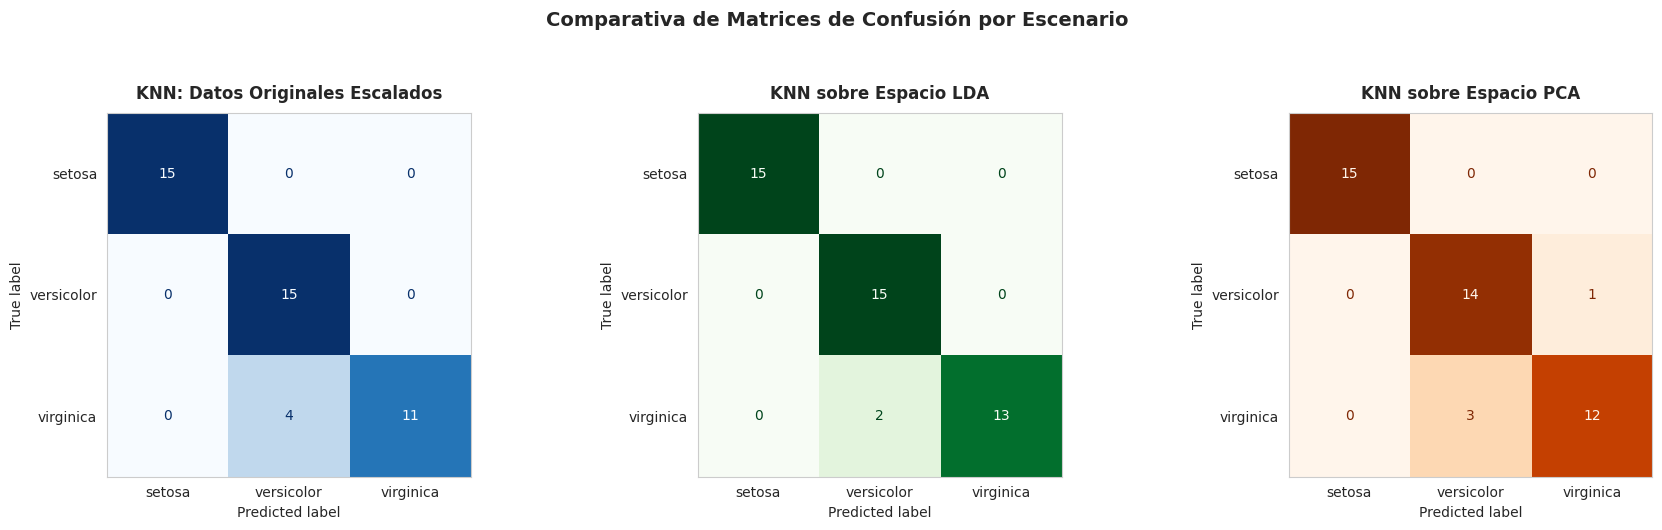

In [12]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)

# 1. Calcular las matrices de confusión para cada escenario
cm_original = confusion_matrix(y_test, y_pred_orig)
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_pca = confusion_matrix(y_test, y_pred_pca)

# 2. Configurar el lienzo con 3 subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
especies = iris_data.target_names  # ['setosa', 'versicolor', 'virginica']

# Matriz 1: Datos Originales Escalados
disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=especies)
disp_orig.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('KNN: Datos Originales Escalados', fontweight='bold', pad=10)

# Matriz 2: Espacio LDA (2 Componentes)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=especies)
disp_lda.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('KNN sobre Espacio LDA', fontweight='bold', pad=10)

# Matriz 3: Espacio PCA (2 Componentes)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=especies)
disp_pca.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('KNN sobre Espacio PCA', fontweight='bold', pad=10)

# Ajustes cosméticos generales
for ax in axes:
    ax.grid(False)  # Quitar líneas de cuadrícula internas de la matriz

plt.suptitle('Comparativa de Matrices de Confusión por Escenario', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Seccion 4: Asignación de nuevos solicitantes (new neighbors)

In [32]:
import warnings
warnings.filterwarnings('ignore', message = 'X no tiene un nombre valido para la feature')

#Nueva Planta solicitada con las siguientes características. ¿A qué especie podría pertenecer?..
sepal_length = 4.5
sepal_width = 2.3
petal_length = 2.95
petal_width = 1.23

solicitante1 = pd.DataFrame({
    'sepal length (cm)': [sepal_length],
    'sepal width (cm)': [sepal_width],
    'petal length (cm)': [petal_length],
    'petal width (cm)': [petal_width]
})

#Obtener clasificador en un espacio LDA y luego escalar.
clasificador = knn_lda
solicitante1_scaled = scaler.transform(solicitante1)
solicitante1_lda = lda_model.transform(solicitante1_scaled)

#Obtener prediccion de especie y la probabilidad de pertenencia.

predicted_species_idx = clasificador.predict(solicitante1_lda) [0]
species_name = especies[predicted_species_idx]
prediction_probabilities = clasificador.predict_proba(solicitante1_lda)[0]


print(f'Especie a la que pertenece la nueva planta solicitada → {species_name}')
print(f'Probabilidad de pertenecer a cada especie → {prediction_probabilities}')


Especie a la que pertenece la nueva planta solicitada → versicolor
Probabilidad de pertenecer a cada especie → [0. 1. 0.]


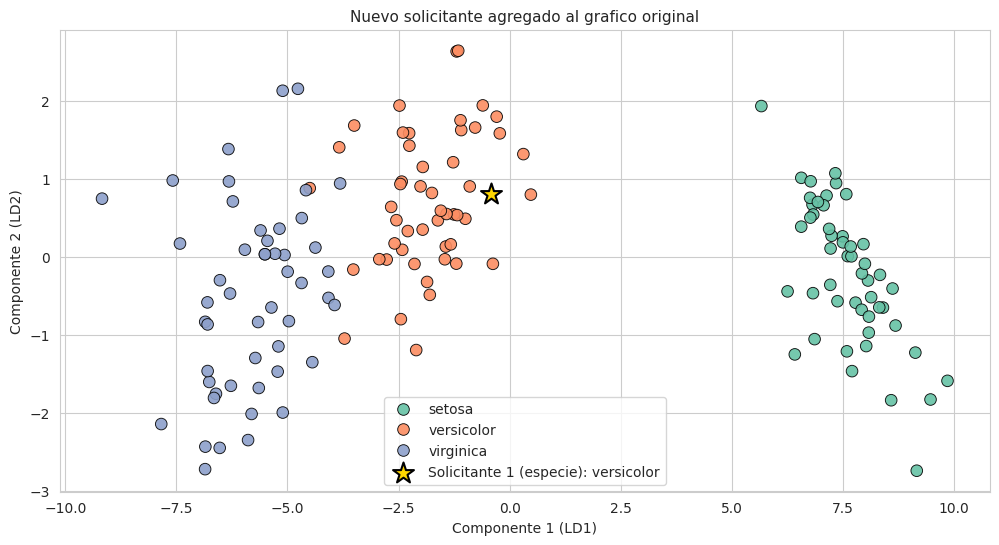

In [40]:
#Grafica

plt.figure(figsize = (12, 6))
sns.scatterplot(
    x = X_LDA[:, 0],
    y = X_LDA[:, 1],
    hue = df['species'],
    palette = 'Set2',
    s=70,
    alpha = 0.9,
    edgecolor = 'k'

)
plt.scatter(solicitante1_lda[:, 0], solicitante1_lda[:, 1], color='gold', marker='*', s=250, edgecolor='black',linewidth=1.5, label=f'Solicitante 1 (especie): {species_name}')

#Estetica original del grafico

plt.title('Nuevo solicitante agregado al grafico original', fontsize=11)
plt.xlabel('Componente 1 (LD1)')
plt.ylabel('Componente 2 (LD2)')
plt.legend()
plt.grid(True)
plt.show()

## 🔹 Sección 5: Reflexión Crítica

### ❓ Pregunta 4.1
> Responde brevemente (3-5 líneas cada una):
>
> a) ¿Qué ventajas tiene LDA frente a PCA para problemas de clasificación?  
> b) ¿Qué supuestos estadísticos debe cumplir LDA? ¿Qué ocurre si no se cumplen?  
> c) ¿En qué tipos de problemas recomendarías usar LDA y en cuáles no? Justificá.

a) La principal ventaja es que LDA **es supervisado**, lo que significa que utiliza las etiquetas de clase para encontrar los ejes que maximizan la separación entre grupos. En cambio, PCA es **no supervisado** y busca las direcciones de máxima varianza global a ciegas.

b) LDA asume que las variables predictoras siguen una distribución normal multivariada, que tienen la misma matriz de covarianza en todas las clases (homocedasticidad) y que no hay multicolinealidad extrema.

c) Lo recomendaría en problemas con múltiples clases bien definidas, variables numéricas continuas de distribución acampanada y muestras limitadas (como la clasificación de tipos de clientes o biomarcadores médicos), donde se busque un modelo rápido, lineal e interpretable.

### ❓ Pregunta 4.2
> Imaginá que trabajás con un dataset con 10 clases y 50 características. ¿Cuántos componentes discriminantes podría generar LDA como máximo? ¿Sería suficiente para visualización? ¿Qué alternativas considerarías?

 * La regla matemática dictamina que el límite superior está dado por $\min(n_{\text{características}}, \, n_{\text{clases}} - 1)$.  En este escenario:$n_{\text{características}} = 50$$n_{\text{clases}} - 1 = 10 - 1 = 9$Como $9 < 50$, el tope matemático queda fijado de forma estricta en 9 dimensiones.

 * No, no sería suficiente. Los seres humanos solo podemos interpretar y procesar visualmente gráficos en 2D (plano cartesiano) o 3D (espacio tridimensional con rotación).

 * Si el objetivo primordial es exclusivamente la visualización de las 10 clases en un mapa intuitivo, existen alternativas modernas y mucho más potentes para manejar altas dimensiones.

---
## 📤 Instrucciones de Entrega
1. Ejecutá **todas** las celdas del notebook (`Kernel > Run All`).
2. Verificá que los gráficos y resultados se muestren correctamente.
3. Guardá el notebook con celdas de salida incluidas (`File > Download as > Notebook (.ipynb)`).
4. Subí el archivo a la plataforma de la cátedra antes de la fecha límite.

> ⚠️ **Importante:** No se aceptarán notebooks que no puedan ejecutarse de forma limpia desde el inicio. Verificá que no haya dependencias externas no declaradas.